# How to Compare Resource Requirements of Subroutine Variants

This how-to guide walks you through the high-level steps of comparing resource requirements of several variants of a quantum subroutine, using the number of Toffoli gates as an example metric.

The task of identifying the best implementation of a subroutine is an important part of realizing quantum speedup for a larger application.
You can read more about the workflow of comparing different implementation of the same subroutine in [QRE Analysis for Arithmetic Variants](../tutorials/QRE-Analysis-for-Arithmetic-Variants.ipynb).


## Step 1. Implement the subroutine variants

Implement each variant of the subroutine that you want to analyze as a Qubrick as described in [How to Define and Use a High-level Routine](./Define-Use-Routine.ipynb). For this guide, we'll use built-in Workbench Qubricks that perform [in-place addition](../tutorials/Quantum-Arithmetic.ipynb#in-place-addition).

```python
from psiqdk.workbench.arithmetic import CuccaroAdd, GidneyAdd, NaiveAdd
```


## Step 2. Get resource estimates for each variant

Write the Workbench code to get the resource estimates of the metric you want to explore for a given problem instance for a given subroutine. Follow the steps outlined in [How to Get a Numeric Resource Estimate](./Get-Numeric-Resource-Estimate.ipynb).

```python
def get_adder_toffoli_count(reg_size: int, adder: Qubrick):
    qpu = QPU(num_qubits=3 * reg_size, filters=NO_SIM_DEFAULT)
    lhs, rhs = Qubits(reg_size, "lhs", qpu), Qubits(reg_size, "rhs", qpu)
    adder.compute(lhs, rhs)
    resources = resource_estimator(qpu).resources()
    # Left Gidney elbows are equivalent to Toffoli gates here, so we return the sum of two metrics
    return resources["toffs"] + resources["gidney_lelbows"]
```


## Step 3. Analyze resource estimates

Now, you can get the numeric values of resource estimates for each variant of a subroutine you want to analyze and for any problem instances you want. At this point, you can compare them and analyze them using standard Python tools, for example, by plotting the resource requirements as a function of the input sizes.


## Example

The following example shows how to get Toffoli counts for three implementations of in-place addition: "naive", Gidney, and Cuccaro adders. It then plots these counts for increasing sizes of quantum registers used to perform addition.

> You can find a more sophisticated example of comparing these adders in [QRE Analysis for Arithmetic Variants](../tutorials/QRE-Analysis-for-Arithmetic-Variants.ipynb).

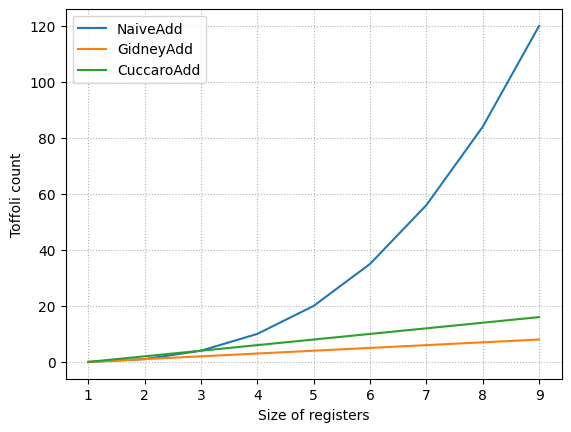

In [1]:
from psiqdk.workbench import QPU, Qubits, Qubrick
from psiqdk.workbench.filter_presets import NO_SIM_DEFAULT
from psiqdk.workbench.arithmetic import CuccaroAdd, GidneyAdd, NaiveAdd
from psiqdk.workbench.qre import resource_estimator
import matplotlib.pyplot as plt

def get_adder_toffoli_count(reg_size: int, adder: Qubrick):
    '''Get Toffoli count for in-place addition using the given adder
       for the given size of input registers.'''
    qpu = QPU(num_qubits=3 * reg_size, filters=NO_SIM_DEFAULT)
    lhs, rhs = Qubits(reg_size, "lhs", qpu), Qubits(reg_size, "rhs", qpu)
    adder.compute(lhs, rhs)
    resources = resource_estimator(qpu).resources()
    # Left Gidney elbows are equivalent to Toffoli gates here, so we return the sum of two metrics
    return resources["toffs"] + resources["gidney_lelbows"]


# Fetch the data for all three adders for a range of input sizes
reg_sizes = list(range(1, 10))
toffoli_counts = {}
for adder in [NaiveAdd(), GidneyAdd(), CuccaroAdd()]:
    label = adder.__class__.__name__
    counts = [get_adder_toffoli_count(reg_size, adder) for reg_size in reg_sizes]
    toffoli_counts[label] = counts

# Plot the results
for label, counts in toffoli_counts.items():
    plt.plot(reg_sizes, counts, label=label)
plt.xticks(reg_sizes)
plt.grid(linestyle=":")
plt.xlabel("Size of registers")
plt.ylabel("Toffoli count")
_ = plt.legend()